In [1]:
#Assignment 1

import pandas as pd

# Load the Titanic dataset directly from a web URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display basic information about the dataset structure
print("--- Dataset Info ---")
df.info()

# Display statistical summary of numerical columns
print("\n--- Statistical Summary ---")
print(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Statistical Summary ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118

In [2]:
#Assignment 2

# Check for missing values
print("Missing values per column before imputation:")
print(df.isnull().sum())

# Fill missing numerical values in 'Age' with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' values with the most common value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values per column before imputation:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after imputation:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [3]:
#Assignment3

from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding for 'Sex' (Transforms 'male'/'female' to 0 and 1)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# 2. One-Hot Encoding for 'Embarked' (Creates separate columns for ports C, Q, S)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Look at the newly formatted dataframe
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,False,True


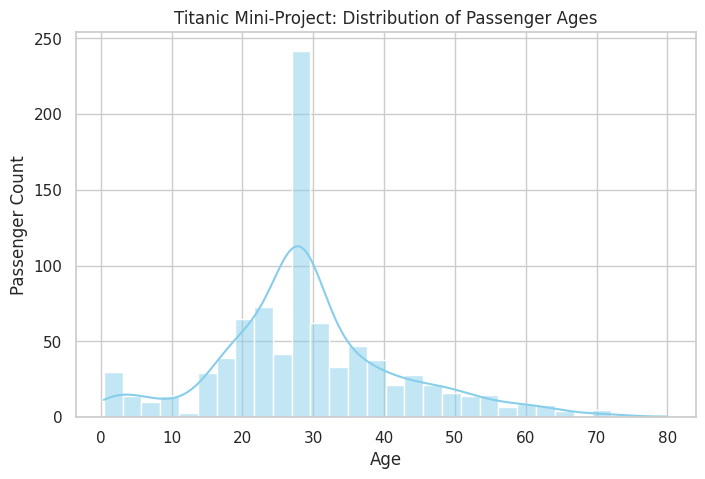


[SUCCESS] Mini-Project Complete! 'cleaned_titanic_data.csv' has been generated.


In [6]:
# Mini project 1:"Titanic Survival Prediction - Data cleaning Project"


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Load the Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Clean Missing Data (Imputation)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Encode Categorical Columns (Sex and Embarked)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# 4. Visualize Age Distribution (Matplotlib/Seaborn)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=30)
plt.title('Titanic Mini-Project: Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Passenger Count')
plt.show()  # Renders the histogram directly in your notebook

# 5. Output Cleaned Dataset as a New CSV
df.to_csv('cleaned_titanic_data.csv', index=False)
print("\n[SUCCESS] Mini-Project Complete! 'cleaned_titanic_data.csv' has been generated.")